In [72]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [73]:
# Core stack (CPU)
!pip install numpy==1.26.4
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1

# Utilities
!pip install pandas==2.2.2 scikit-learn==1.5.1 matplotlib==3.9.0 tqdm==4.66.4 pillow==10.3.0


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement torch==2.3.1 (from versions: 2.2.0, 2.2.1, 2.2.2)
ERROR: No matching distribution found for torch==2.3.1

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [74]:
pip install --upgrade "numpy==1.26.4" "scipy==1.11.4" "scikit-learn==1.4.2"

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import yaml
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import cv2
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# Load configuration
with open('Human Bone Fractures Multi-modal Image Dataset (HBFMID) main/Bone Fractures Detection/data.yaml') as f:
    data_config = yaml.safe_load(f)

In [3]:
data_config

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 10,
 'names': ['Comminuted',
  'Greenstick',
  'Healthy',
  'Linear',
  'Oblique Displaced',
  'Oblique',
  'Segmental',
  'Spiral',
  'Transverse Displaced',
  'Transverse'],
 'roboflow': {'workspace': 'iubat-i4ldm',
  'project': 'bon-fracture-detection',
  'version': 2,
  'license': 'Private',
  'url': 'https://app.roboflow.com/iubat-i4ldm/bon-fracture-detection/2'}}

In [4]:
# Parameters
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
NUM_EPOCHS = 25
LEARNING_RATE = 0.0005
NUM_CLASSES = len(data_config['names'])
CLASS_NAMES = data_config['names']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
CLASS_NAMES

['Comminuted',
 'Greenstick',
 'Healthy',
 'Linear',
 'Oblique Displaced',
 'Oblique',
 'Segmental',
 'Spiral',
 'Transverse Displaced',
 'Transverse']

In [6]:
# Enhanced Dataset
class BoneFractureDataset(Dataset):
    def __init__(self, root_dir, transform=None, mode='train'):
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode
        self.image_dir = os.path.join(root_dir, mode, 'images')
        self.label_dir = os.path.join(root_dir, mode, 'labels')
        self.image_files = [f for f in os.listdir(self.image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_name)
        
        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            with open(label_path, 'r') as f:
                label = int(f.readline().strip().split()[0])
        else:
            label = 0
            
        if self.transform:
            image = self.transform(image)
            
        return image, label


In [7]:
root_dir='Human Bone Fractures Multi-modal Image Dataset (HBFMID) main/Bone Fractures Detection'
transform = None
mode='train'
image_dir = os.path.join(root_dir, mode, 'images')
#image_dir
label_dir = os.path.join(root_dir, mode, 'labels')
#label_dir
image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
image_files

['109_jpg.rf.01416c82b8d3058659f39908b55f19b6.jpg',
 '18_jpg.rf.3114fe40b4af86f21cd3520349cae8ce.jpg',
 '118_jpg.rf.003d7f30da7698ba2b8689147570afe8.jpg',
 '1_new_xr_jpeg.rf.e44228054a5466be65ef025be3a74a44.jpg',
 '112_jpg.rf.51ac5a8fd0e77347833b463eccc8a12c.jpg',
 '195_jpg.rf.681cf06009203b8d3a6efca02116e498.jpg',
 '58_jpg.rf.e57b879814d534f08d75dc5b34737dcd.jpg',
 '33_jpg.rf.5f93dac5c6a9788cd6c3ca62310a25be.jpg',
 '85_jpg.rf.aaeb1c2f9144d168513944a9072ecb18.jpg',
 '102_jpg.rf.eb04297826c0635e89c75f5b2503d7d0.jpg',
 '58_jpg.rf.2327e8549168454a582b0b0e72c4a84d.jpg',
 '56_jpg.rf.01e89192a51da3b2eb2df0cf8af3bcab.jpg',
 '39_jpg.rf.5fe390ad67dbaff33d02afbcb1492a37.jpg',
 '26_jpg.rf.f48681d872ad6efe26c9b349d3c1ffbc.jpg',
 '190_jpg.rf.fdb3cfdd2d6e478e6556236805e014c1.jpg',
 '132_jpg.rf.25e9c32054c75f95c01996cdc397fc86.jpg',
 '182_jpg.rf.86f972841e1ed461a4ad8222bad091cc.jpg',
 '15_jpg.rf.5db72f2d0a114de0ea22d00416ea4d54.jpg',
 '26_mri_0_7467_jpeg.rf.a14983102a995095c89ff14dae8a0745.jpg',
 '11

In [8]:
# Enhanced Augmentation
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [9]:
# Create datasets
train_dataset = BoneFractureDataset(
    root_dir='Human Bone Fractures Multi-modal Image Dataset (HBFMID) main/Bone Fractures Detection',
    transform=train_transform,
    mode='train'
)

val_dataset = BoneFractureDataset(
    root_dir='Human Bone Fractures Multi-modal Image Dataset (HBFMID) main/Bone Fractures Detection',
    transform=val_transform,
    mode='valid'
)

test_dataset = BoneFractureDataset(
    root_dir='Human Bone Fractures Multi-modal Image Dataset (HBFMID) main/Bone Fractures Detection',
    transform=val_transform,
    mode='test'
)

In [10]:
# Check class distribution
def check_class_distribution(dataset, name):
    counts = torch.zeros(NUM_CLASSES)
    for _, label in dataset:
        counts[label] += 1
    print(f"\nClass distribution in {name} set:")
    for i, count in enumerate(counts):
        print(f"Class {i} ({CLASS_NAMES[i]}): {int(count)} samples")

check_class_distribution(train_dataset, 'train')
check_class_distribution(val_dataset, 'validation')
check_class_distribution(test_dataset, 'test')



Class distribution in train set:
Class 0 (Comminuted): 153 samples
Class 1 (Greenstick): 75 samples
Class 2 (Healthy): 54 samples
Class 3 (Linear): 21 samples
Class 4 (Oblique Displaced): 297 samples
Class 5 (Oblique): 48 samples
Class 6 (Segmental): 12 samples
Class 7 (Spiral): 66 samples
Class 8 (Transverse Displaced): 531 samples
Class 9 (Transverse): 90 samples

Class distribution in validation set:
Class 0 (Comminuted): 14 samples
Class 1 (Greenstick): 7 samples
Class 2 (Healthy): 7 samples
Class 3 (Linear): 1 samples
Class 4 (Oblique Displaced): 28 samples
Class 5 (Oblique): 7 samples
Class 6 (Segmental): 3 samples
Class 7 (Spiral): 5 samples
Class 8 (Transverse Displaced): 47 samples
Class 9 (Transverse): 9 samples

Class distribution in test set:
Class 0 (Comminuted): 9 samples
Class 1 (Greenstick): 1 samples
Class 2 (Healthy): 3 samples
Class 3 (Linear): 0 samples
Class 4 (Oblique Displaced): 16 samples
Class 5 (Oblique): 2 samples
Class 6 (Segmental): 0 samples
Class 7 (Spir

In [11]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

In [12]:
# Enhanced Model
class FractureClassifier(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Step 1: Initialize base model architecture
        self.base_model = models.efficientnet_b4(weights=None)

        # Step 2: Load local weights
        local_weights_path = "efficientnet_b4_rwightman-23ab8bcd.pth"  # change path if needed
        state_dict = torch.load(local_weights_path, map_location=torch.device('cpu'))
        self.base_model.load_state_dict(state_dict)
        num_ftrs = self.base_model.classifier[1].in_features
        
        self.attention_gate = torch.nn.Sequential(
            torch.nn.Conv2d(num_ftrs, num_ftrs//8, kernel_size=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(num_ftrs//8, 1, kernel_size=1),
            torch.nn.Sigmoid()
        )
        
        self.classifier = torch.nn.Sequential(
            torch.nn.Dropout(0.5),
            torch.nn.Linear(num_ftrs, 512),
            torch.nn.BatchNorm1d(512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.base_model.features(x)
        attention = self.attention_gate(features)
        attended_features = features * attention
        pooled = torch.nn.functional.adaptive_avg_pool2d(attended_features, (1, 1))
        flattened = torch.flatten(pooled, 1)
        return self.classifier(flattened), attention

model = FractureClassifier(NUM_CLASSES).to(device)


In [13]:
# Enhanced Class Weighting
def get_enhanced_class_weights(dataset):
    y = [label for _, label in dataset]
    class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
    
    weight_multipliers = {
        'Comminuted': 3.0,
        'Transverse Displaced': 2.0,
        'Healthy': 0.7,
        'Oblique Displaced': 1.5
    }
    
    for cls, mult in weight_multipliers.items():
        if cls in CLASS_NAMES:
            idx = CLASS_NAMES.index(cls)
            class_weights[idx] *= mult
    
    return torch.tensor(class_weights, dtype=torch.float).to(device)

class_weights = get_enhanced_class_weights(train_dataset)


In [64]:
def get_enhanced_class_weights(dataset):
    from collections import Counter

    # Get number of classes from class names
    num_classes = len(CLASS_NAMES)

    # Initialize class weights as 1 for each class
    class_weights = [1.0] * num_classes

    # Count occurrences of each class in dataset
    class_counts = Counter([label for _, label in dataset])

    # Optional: Inverse frequency multiplier (or use your own logic)
    for cls, count in class_counts.items():
        if isinstance(cls, str):
            idx = CLASS_NAMES.index(cls)
        else:
            idx = cls  # assumes label is already an integer class index

        mult = 1.0 / (count + 1e-5)
        if idx < len(class_weights):
            class_weights[idx] *= mult
        else:
            raise IndexError(f"Class index {idx} exceeds class_weights length {len(class_weights)}")

    return torch.tensor(class_weights, dtype=torch.float).to(device)

class_weights = get_enhanced_class_weights(train_dataset)

In [14]:
# Hybrid Loss
class HybridLoss(torch.nn.Module):
    def __init__(self, alpha=None, gamma=2.0, ce_weight=0.3):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.ce_weight = ce_weight
        self.ce_loss = torch.nn.CrossEntropyLoss(weight=alpha)

    def forward(self, inputs, targets):
        ce = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce)
        focal_loss = ((1 - pt) ** self.gamma * ce).mean()
        return self.ce_weight * ce + (1 - self.ce_weight) * focal_loss

criterion = HybridLoss(alpha=class_weights, gamma=2.0, ce_weight=0.4)


In [15]:
# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)


In [16]:
# Early Stopping
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_acc = None
        self.early_stop = False

    def __call__(self, val_acc):
        if self.best_acc is None:
            self.best_acc = val_acc
        elif val_acc < self.best_acc + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_acc = val_acc
            self.counter = 0
        return self.early_stop

early_stopping = EarlyStopping(patience=7)


In [25]:
# Training function
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader
                
            running_loss = 0.0
            running_corrects = 0
            
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs, _ = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            
            if phase == 'val':
                scheduler.step(epoch_acc)
                
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), 'best_model.pth')
                    print(f'Model saved with validation accuracy: {best_acc:.4f}')
                
                if early_stopping(epoch_acc):
                    print("Early stopping triggered!")
                    return model, history
    
    print(f'\nBest validation Accuracy: {best_acc:.4f}')
    return model, history

# Train the model
NUM_EPOCHS = 100
model, history = train_model(model, criterion, optimizer, scheduler, NUM_EPOCHS)



Epoch 1/100
----------
train Loss: 0.0162 Acc: 0.9800
val Loss: 0.0723 Acc: 0.9297
Model saved with validation accuracy: 0.9297
Early stopping triggered!


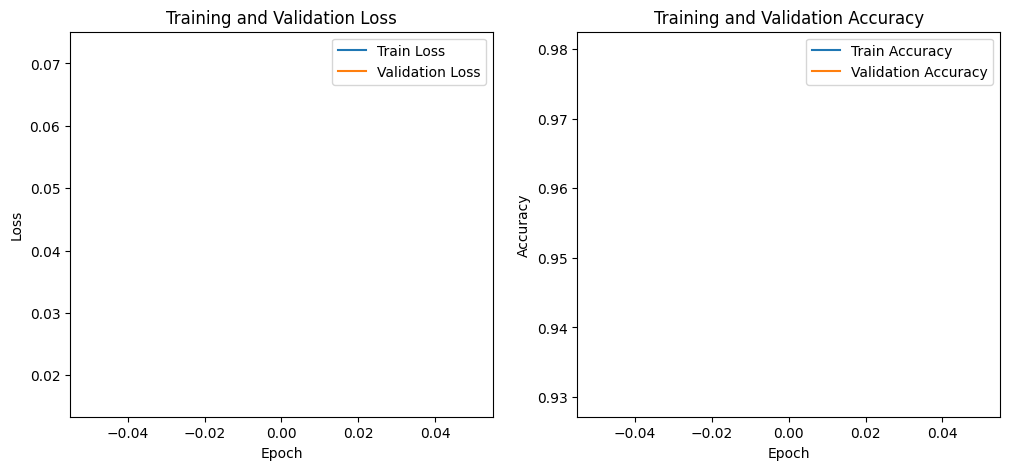

In [26]:
# Plot training history
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_training_history(history)


In [27]:
# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    attention_maps = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs, attention = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            attention_maps.extend(attention.cpu().numpy())
    
    present_classes = np.unique(all_labels)
    present_class_names = [CLASS_NAMES[i] for i in present_classes]
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, 
                              target_names=present_class_names,
                              labels=present_classes,
                              zero_division=0))
    
    cm = confusion_matrix(all_labels, all_preds, labels=present_classes)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=present_class_names,
               yticklabels=present_class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return all_preds, all_labels, all_probs, attention_maps



Evaluating on test set...

Classification Report:
                      precision    recall  f1-score   support

          Comminuted       1.00      0.78      0.88         9
          Greenstick       1.00      1.00      1.00         1
             Healthy       1.00      1.00      1.00         3
   Oblique Displaced       0.94      1.00      0.97        16
             Oblique       1.00      1.00      1.00         2
              Spiral       1.00      1.00      1.00         3
Transverse Displaced       1.00      0.95      0.98        22
          Transverse       0.80      1.00      0.89         8

            accuracy                           0.95        64
           macro avg       0.97      0.97      0.96        64
        weighted avg       0.96      0.95      0.95        64



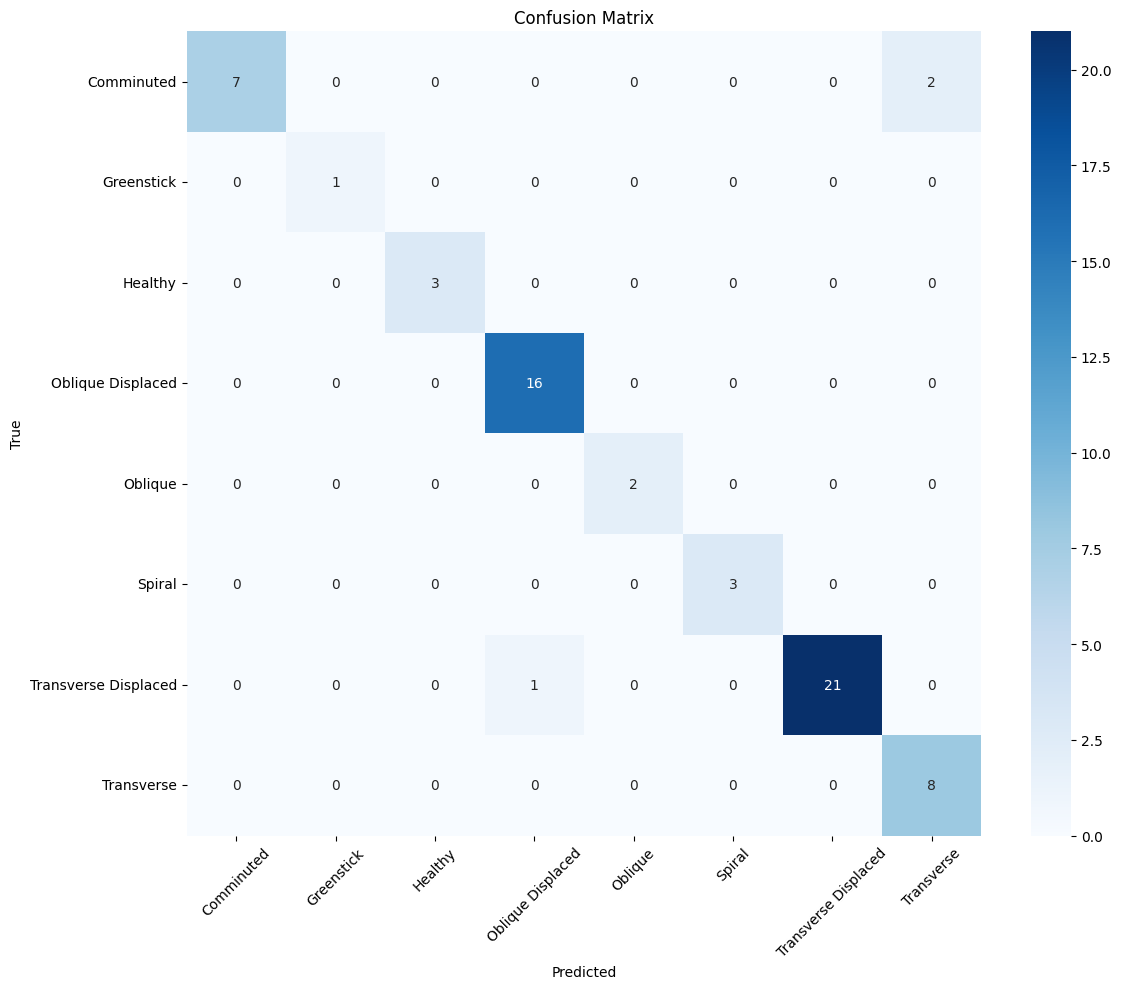

In [28]:
# Load best model and evaluate
model.load_state_dict(torch.load('best_model.pth'))
print("\nEvaluating on test set...")
predictions, true_labels, probabilities, attentions = evaluate_model(model, test_loader)



Total errors: 3/64


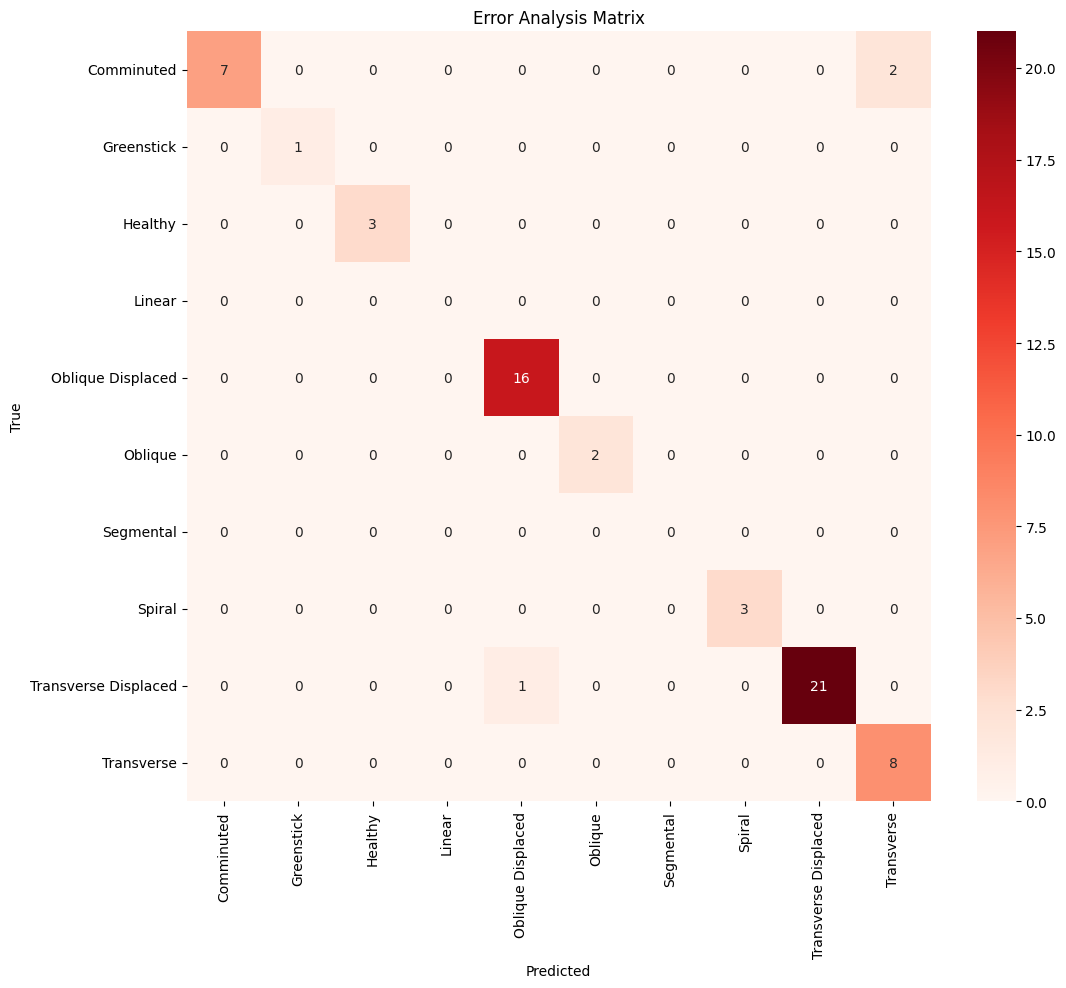


Critical Error Analysis:
Comminuted → Transverse Displaced: 0.0 errors
Transverse Displaced → Healthy: 0.0 errors


In [29]:
# Error analysis
def analyze_errors(true_labels, pred_labels, class_names):
    error_indices = np.where(np.array(true_labels) != np.array(pred_labels))[0]
    print(f"\nTotal errors: {len(error_indices)}/{len(true_labels)}")
    
    error_matrix = np.zeros((len(class_names), len(class_names)))
    for true, pred in zip(true_labels, pred_labels):
        error_matrix[true, pred] += 1
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(error_matrix, annot=True, fmt='g', cmap='Reds',
               xticklabels=class_names,
               yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Error Analysis Matrix')
    plt.show()
    
    # Critical error analysis
    critical_pairs = [('Comminuted', 'Transverse Displaced'),
                     ('Transverse Displaced', 'Healthy')]
    
    print("\nCritical Error Analysis:")
    for true_class, pred_class in critical_pairs:
        if true_class in class_names and pred_class in class_names:
            true_idx = class_names.index(true_class)
            pred_idx = class_names.index(pred_class)
            count = error_matrix[true_idx, pred_idx]
            print(f"{true_class} → {pred_class}: {count} errors")

analyze_errors(true_labels, predictions, CLASS_NAMES)


In [30]:
# Grad-CAM Visualization
def visualize_gradcam(model, test_loader, class_names, num_samples=3):
    model.eval()
    
    # Hook for feature maps
    feature_maps = []
    def forward_hook(module, input, output):
        feature_maps.append(output.detach())
    
    # Using full backward hook
    gradients = []
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())
    
    # Register hooks to the last convolutional layer
    target_layer = model.base_model.features[-1]
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)
    
    try:
        # Get sample images
        samples = []
        sample_labels = []
        for inputs, labels in test_loader:
            samples.extend(inputs[:num_samples])
            sample_labels.extend(labels[:num_samples])
            if len(samples) >= num_samples:
                break
        
        if not samples:
            print("Warning: No samples found in test loader!")
            return
            
        for img_tensor, label in zip(samples[:num_samples], sample_labels[:num_samples]):
            img_tensor = img_tensor.to(device).unsqueeze(0)
            img_tensor.requires_grad_(True)
            
            # Forward pass
            outputs, _ = model(img_tensor)
            _, pred_idx = torch.max(outputs, 1)
            
            # Backward pass
            model.zero_grad()
            outputs[0, pred_idx].backward(retain_graph=True)
            
            # Process gradients and features
            if not gradients or not feature_maps:
                print("Warning: No gradients or feature maps captured!")
                continue
                
            grads = gradients[-1]
            pooled_grads = torch.mean(grads, dim=[0, 2, 3], keepdim=True)
            feature_map = feature_maps[-1]
            
            # Weight the feature maps
            weighted_features = feature_map * pooled_grads
            heatmap = torch.mean(weighted_features, dim=1, keepdim=True)
            heatmap = torch.nn.functional.relu(heatmap)
            heatmap = heatmap / (torch.max(heatmap) + 1e-6)
            
            # Prepare visualization
            img = img_tensor.squeeze().cpu().detach().numpy()
            img = img.transpose(1, 2, 0)  # Change from (C, H, W) to (H, W, C)
            
            # Denormalize image
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = img * std + mean  # Proper denormalization
            img = np.clip(img, 0, 1)
            
            # Process heatmap
            heatmap = heatmap.squeeze().cpu().detach().numpy()
            heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
            heatmap = np.uint8(255 * heatmap)
            heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
            
            # Superimpose heatmap on image
            superimposed_img = cv2.addWeighted((img * 255).astype(np.uint8), 0.6, heatmap, 0.4, 0)
            
            # Create figure
            plt.figure(figsize=(18, 6))
            
            # Original image
            plt.subplot(1, 3, 1)
            plt.imshow(img)
            plt.title(f'Original\nTrue: {class_names[label]}')
            plt.axis('off')
            
            # Grad-CAM
            plt.subplot(1, 3, 2)
            plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
            plt.title(f'Grad-CAM\nPred: {class_names[pred_idx.item()]}')
            plt.axis('off')
            
            # Attention map
            with torch.no_grad():
                _, attention = model(img_tensor)
                attention = attention.squeeze().cpu().detach().numpy()
                attention = cv2.resize(attention, (img.shape[1], img.shape[0]))
                
                plt.subplot(1, 3, 3)
                plt.imshow(attention, cmap='hot')
                plt.title('Attention Map')
                plt.axis('off')
                plt.colorbar()
            
            plt.tight_layout()
            plt.show()
            
            # Clear for next iteration
            feature_maps.clear()
            gradients.clear()
    
    except Exception as e:
        print(f"Error during Grad-CAM visualization: {str(e)}")
        import traceback
        traceback.print_exc()
    
    finally:
        # Remove hooks
        forward_handle.remove()
        backward_handle.remove()



No critical errors found for visualization

Visualizing Random Samples with Grad-CAM...


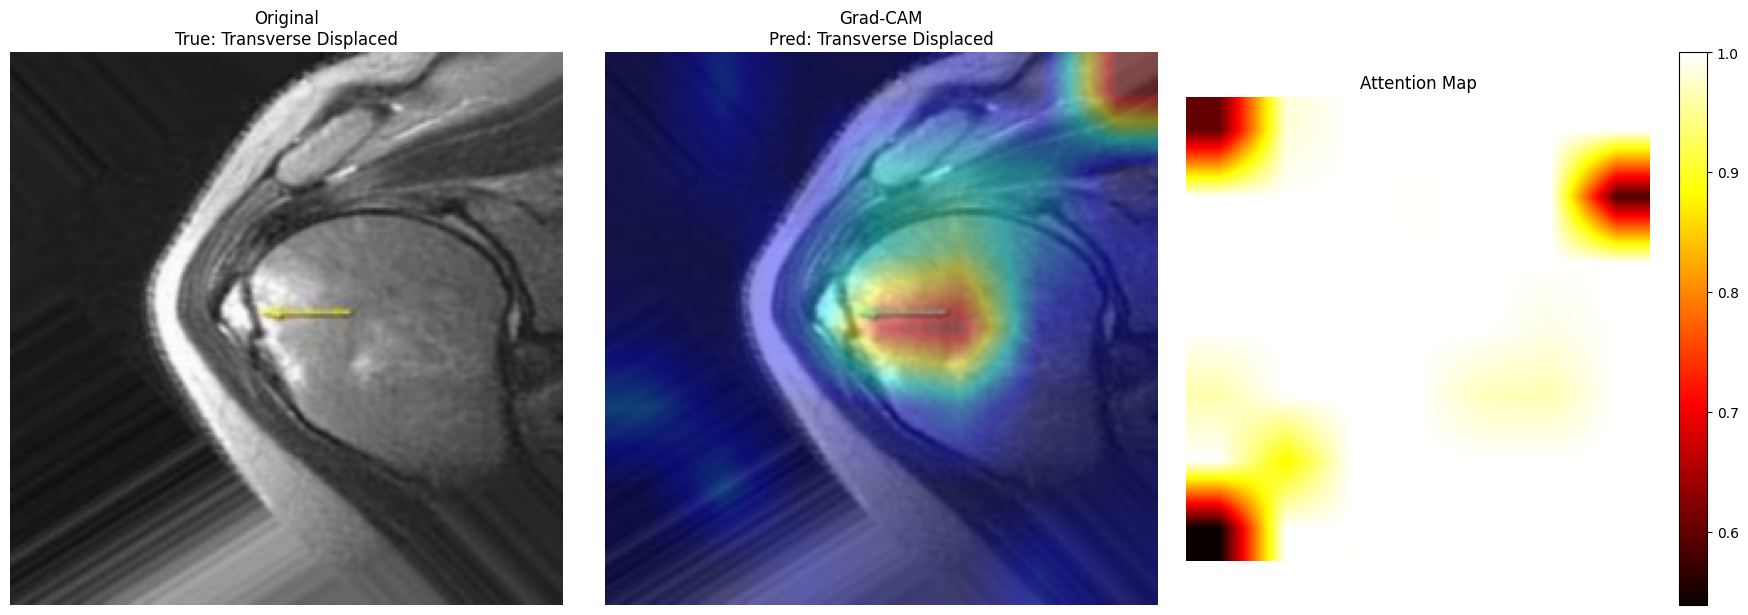

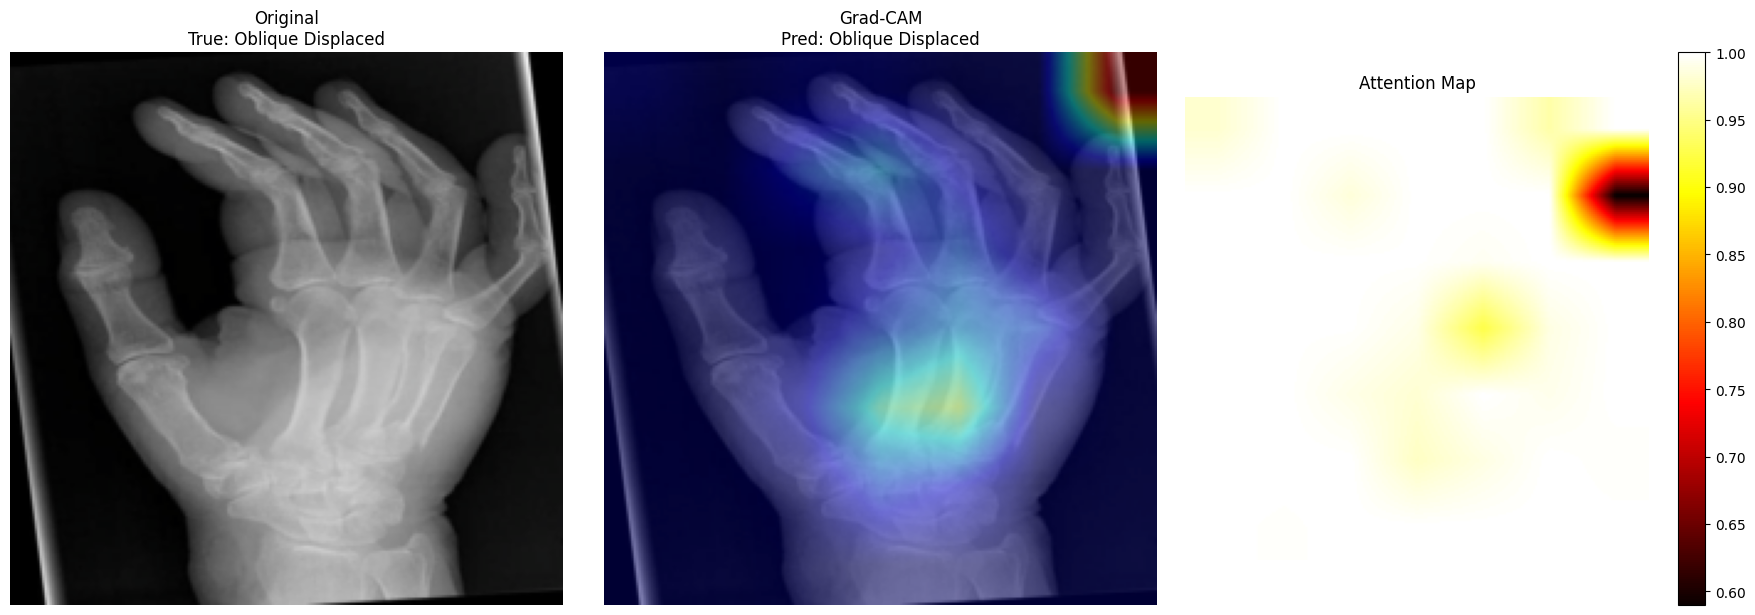

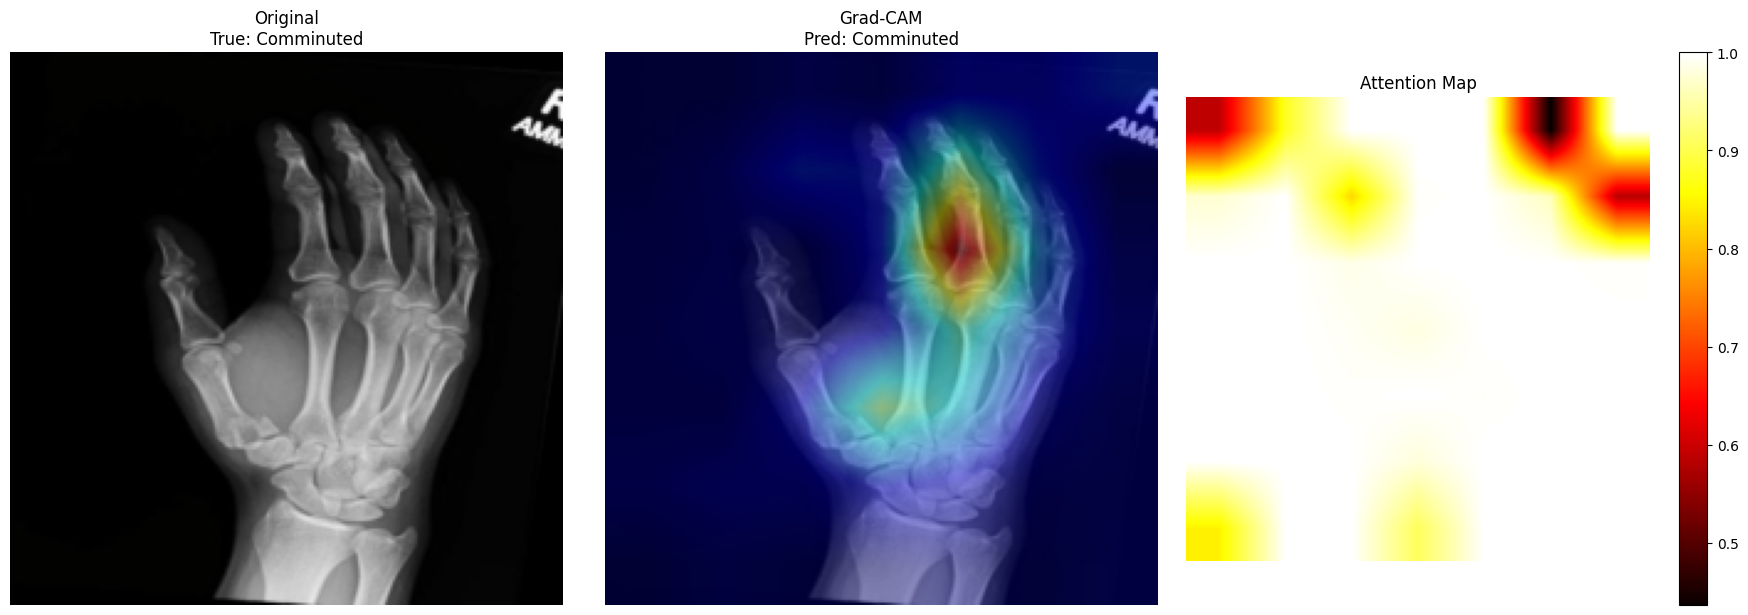

In [31]:
# Visualize critical cases if any exist
critical_indices = [i for i, (true, pred) in enumerate(zip(true_labels, predictions))
                   if (CLASS_NAMES[true] == 'Comminuted' and CLASS_NAMES[pred] == 'Transverse Displaced') or
                   (CLASS_NAMES[true] == 'Transverse Displaced' and CLASS_NAMES[pred] == 'Healthy')]

if len(critical_indices) > 0:
    critical_loader = DataLoader(
        torch.utils.data.Subset(test_dataset, critical_indices[:3]),
        batch_size=1, shuffle=False
    )
    print("\nVisualizing Critical Cases with Grad-CAM...")
    visualize_gradcam(model, critical_loader, CLASS_NAMES)
else:
    print("\nNo critical errors found for visualization")

# Visualize random samples
print("\nVisualizing Random Samples with Grad-CAM...")
visualize_gradcam(model, test_loader, CLASS_NAMES)